# Linear Regression Forecasting ML

Complete machine learning model for predicting next day maximum temperature using Linear Regression.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

## Step 1: Load the dataset from CSV

In [3]:
data_path = "../../data/cambodia_weather.csv"
if data_path is None:
    raise FileNotFoundError("Could not find cambodia_weather.csv in expected locations.")

df = pd.read_csv(data_path)
print(f"Loaded dataset from: {data_path}")
print(df.head())

Loaded dataset from: ../../data/cambodia_weather.csv
         date  temp_max  temp_min  rain  wind_speed    province    lat     lon
0  2015-01-01      30.1      20.5   0.0        20.0  Phnom Penh  11.55  104.91
1  2015-01-02      30.0      19.9   0.0        18.7  Phnom Penh  11.55  104.91
2  2015-01-03      31.2      22.6   0.0        16.9  Phnom Penh  11.55  104.91
3  2015-01-04      31.5      22.2   0.0         9.4  Phnom Penh  11.55  104.91
4  2015-01-05      32.2      23.6   0.0         9.7  Phnom Penh  11.55  104.91


In [4]:
# Display dataframe summary
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
display(df.head())
print(f"\nDescriptive Statistics:")
display(df.describe(include='all').round(2))

DATASET SUMMARY

Shape: 20,540 rows × 8 columns

Columns: ['date', 'temp_max', 'temp_min', 'rain', 'wind_speed', 'province', 'lat', 'lon']

First 5 rows:


,date,temp_max,temp_min,rain,wind_speed,province,lat,lon
0,2015-01-01,30.1,20.5,0.0,20.0,Phnom Penh,11.55,104.91
1,2015-01-02,30.0,19.9,0.0,18.7,Phnom Penh,11.55,104.91
2,2015-01-03,31.2,22.6,0.0,16.9,Phnom Penh,11.55,104.91
3,2015-01-04,31.5,22.2,0.0,9.4,Phnom Penh,11.55,104.91
4,2015-01-05,32.2,23.6,0.0,9.7,Phnom Penh,11.55,104.91



Descriptive Statistics:


,date,temp_max,temp_min,rain,wind_speed,province,lat,lon
count,20540,20540.00,20540.00,20540.00,20540.00,20540,20540.00,20540.00
unique,4108,NaN,NaN,NaN,NaN,5,NaN,NaN
top,2026-03-31,NaN,NaN,NaN,NaN,Phnom Penh,NaN,NaN
freq,5,NaN,NaN,NaN,NaN,4108,NaN,NaN
mean,NaN,30.83,23.59,5.24,15.25,NaN,12.22,104.54
std,NaN,3.04,2.59,8.39,5.27,NaN,1.01,1.45
min,NaN,18.20,11.40,0.00,3.80,NaN,10.62,103.20
25%,NaN,28.90,21.90,0.00,11.50,NaN,11.55,103.52
50%,NaN,30.90,24.40,1.70,14.40,NaN,12.45,103.85
75%,NaN,32.70,25.40,7.10,18.00,NaN,13.10,104.91


## Step 2: Convert date column

In [5]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
print(df[["date", "temp_max", "temp_min", "rain", "wind_speed"]].head())

        date  temp_max  temp_min  rain  wind_speed
0 2015-01-01      30.1      20.5   0.0        20.0
1 2015-01-01      24.5      16.1   0.0        29.1
2 2015-01-01      29.0      19.0   0.0        21.3
3 2015-01-01      29.8      23.9   0.3        16.5
4 2015-01-01      29.6      20.1   0.0        13.9


## Step 3: Create target variable

In [6]:
df["temp_max_next"] = df["temp_max"].shift(-1)
print(df[["temp_max", "temp_max_next"]].head())

   temp_max  temp_max_next
0      30.1           24.5
1      24.5           29.0
2      29.0           29.8
3      29.8           29.6
4      29.6           24.0


## Step 4: Create lag features

In [7]:
df["temp_max_lag1"] = df["temp_max"].shift(1)
df["rain_lag1"] = df["rain"].shift(1)
df = df.dropna().reset_index(drop=True)
print(df[["temp_max_lag1", "temp_min", "rain_lag1", "wind_speed", "temp_max_next"]].head())

   temp_max_lag1  temp_min  rain_lag1  wind_speed  temp_max_next
0           30.1      16.1        0.0        29.1           29.0
1           24.5      19.0        0.0        21.3           29.8
2           29.0      23.9        0.0        16.5           29.6
3           29.8      20.1        0.3        13.9           24.0
4           29.6      15.9        0.0        27.7           29.7


## Step 5: Features and target

In [8]:
feature_columns = ["temp_max_lag1", "temp_min", "rain_lag1", "wind_speed"]
X = df[feature_columns]
y = df["temp_max_next"]
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20538, 4)
Target shape: (20538,)


## Step 6: Train and test split

In [9]:
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 16430
Test size: 4108


## Step 7: Train Linear Regression model

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model trained successfully
Coefficients: [ 2.58870888e-01  1.09767871e-01 -3.82768249e-02 -5.05467869e-06]
Intercept: 20.37682654623482


## Step 8: Predictions

In [11]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[30.34116888 31.24101062 31.08736199 30.43417671 30.52104289 29.90191314
 30.95159008 31.05028342 30.2551608  31.30554334]


## Step 9: Evaluation

In [12]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

baseline_pred = X_test["temp_max_lag1"].values
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")
print(f"Baseline RMSE (carry-forward): {baseline_rmse:.2f}")

results = pd.DataFrame({
    "date": df.loc[X_test.index, "date"].values,
    "actual_temp_max_next": y_test.values,
    "pred_temp_max_next": y_pred,
    "abs_error": np.abs(y_test.values - y_pred),
})
results.tail(10)

MAE: 2.27
RMSE: 2.85
R2: 0.1012
Baseline RMSE (carry-forward): 3.48


,date,actual_temp_max_next,pred_temp_max_next,abs_error
4098,2026-03-29,34.5,31.518604,2.981396
4099,2026-03-30,31.2,31.275485,0.075485
4100,2026-03-30,37.9,32.161757,5.738243
4101,2026-03-30,32.2,31.255936,0.944064
4102,2026-03-30,35.5,32.361342,3.138658
4103,2026-03-30,31.3,31.443600,0.143600
4104,2026-03-31,35.2,32.314201,2.885799
4105,2026-03-31,35.7,31.278507,4.421493
4106,2026-03-31,38.2,32.255168,5.944832
4107,2026-03-31,30.4,32.538276,2.138276


## Step 10: Visualization

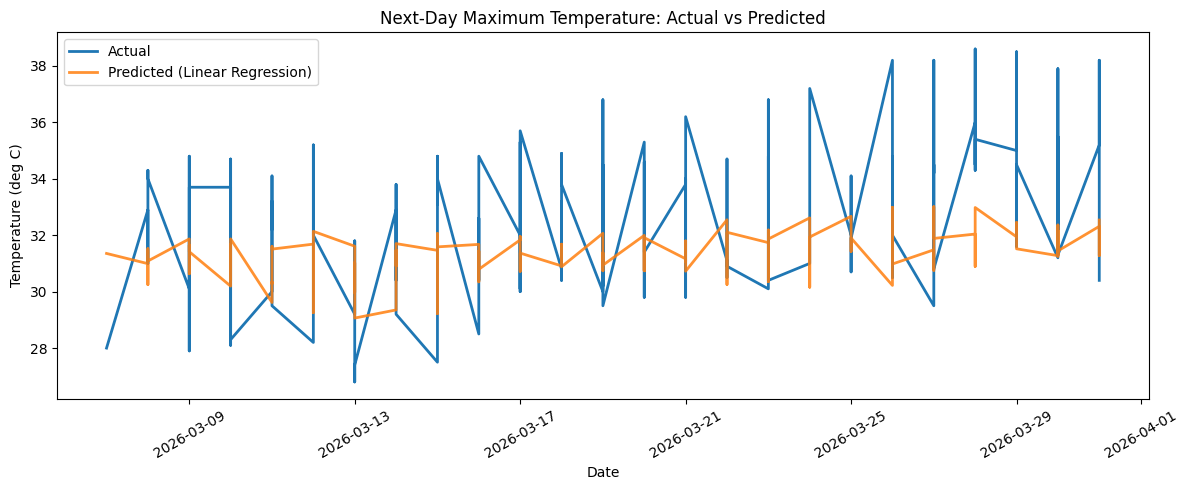

In [13]:
plot_n = min(120, len(results))

plt.figure(figsize=(12, 5))
plt.plot(results["date"].iloc[-plot_n:], results["actual_temp_max_next"].iloc[-plot_n:], label="Actual", linewidth=2)
plt.plot(results["date"].iloc[-plot_n:], results["pred_temp_max_next"].iloc[-plot_n:], label="Predicted (Linear Regression)", linewidth=2, alpha=0.85)
plt.title("Next-Day Maximum Temperature: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Temperature (deg C)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()